In [10]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import librosa.display
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [11]:
def create_melspectrogram(segmented_dir, n_mels=128):
    segmented_dir = Path(segmented_dir)
    X = []
    y = []
    labels = [f.name for f in segmented_dir.iterdir() if f.is_dir()]

    for label in tqdm(labels):
        for audio in (segmented_dir / label).iterdir():
            if audio.suffix == ".wav":
                signal, sr = librosa.load(audio, sr=None)
                melspectrogram = librosa.feature.melspectrogram(y=signal, 
                                                        sr=sr, 
                                                        n_mels=n_mels, 
                                                        fmax=sr/2)
                melspectrogram_db = librosa.power_to_db(melspectrogram, ref=np.max)
                X.append(melspectrogram_db)
                y.append(label)
            
    X = np.array(X)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    return X, np.array(y), label_encoder

Import data for model

In [ ]:
X, y, label_encoder = create_melspectrogram('IRMAS_segmented')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

 55%|█████▍    | 6/11 [00:26<00:23,  4.75s/it]

Plot mel spectrogram

In [ ]:
def plot_melspectrogram(X, i=0):
    melspectrogram_sample = X[i, :, :, 0]
    librosa.display.specshow(melspectrogram_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('Mel Spectrogram')
    plt.xlabel('Time Frames')
    plt.ylabel('Mel Frequency Bands')
    plt.show()

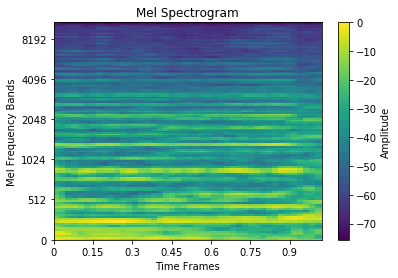

In [ ]:
plot_melspectrogram(X)

CNN model

In [ ]:
cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(X.shape[1], X.shape[2], 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 128, 44, 32)       320       
_________________________________________________________________
batch_normalization (BatchNo (None, 128, 44, 32)       128       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 64, 22, 32)        0         
_________________________________________________________________
dropout (Dropout)            (None, 64, 22, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 64, 22, 64)        18496     
_________________________________________________________________
batch_normalization_1 (Batch (None, 64, 22, 64)        256       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 32, 11, 64)        0

Train CNN

In [ ]:
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

cnn.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/50
403/403 [==============================] - 51s 126ms/step - loss: 2.1436 - accuracy: 0.2580 - val_loss: 3.7589 - val_accuracy: 0.1445
Epoch 2/50
403/403 [==============================] - 57s 142ms/step - loss: 1.7896 - accuracy: 0.3947 - val_loss: 4.3690 - val_accuracy: 0.1417
Epoch 3/50
403/403 [==============================] - 55s 137ms/step - loss: 1.6050 - accuracy: 0.4621 - val_loss: 2.3322 - val_accuracy: 0.3190
Epoch 4/50
403/403 [==============================] - 56s 139ms/step - loss: 1.4966 - accuracy: 0.5023 - val_loss: 2.0950 - val_accuracy: 0.3576
Epoch 5/50
403/403 [==============================] - 52s 129ms/step - loss: 1.4025 - accuracy: 0.5331 - val_loss: 4.9390 - val_accuracy: 0.2075
Epoch 6/50
403/403 [==============================] - 49s 122ms/step - loss: 1.3174 - accuracy: 0.5608 - val_loss: 1.7392 - val_accuracy: 0.4402
Epoch 7/50
403/403 [==============================] - 49s 121ms/step - loss: 1.2594 - accuracy: 0.5784 - val_loss: 4.5900 - val_ac

Evaluate CNN

In [ ]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

# output_file = 'cnn_melspectrogram_evaluation.txt'

# with open(output_file, 'w') as file:
#     file.write(f'Accuracy: {accuracy}\n')
#     file.write('\nClassification Report:\n')
#     file.write(class_report)

# best .74

Accuracy: 0.604772557792692

Classification Report:
               precision    recall  f1-score   support

         cel       0.54      0.60      0.57       233
         cla       0.82      0.43      0.56       303
         flu       0.78      0.33      0.47       271
         gac       0.69      0.69      0.69       382
         gel       0.45      0.68      0.54       456
         org       0.65      0.87      0.75       409
         pia       0.49      0.93      0.64       432
         sax       0.73      0.28      0.40       376
         tru       0.72      0.74      0.73       346
         vio       0.55      0.59      0.57       348
         voi       0.97      0.38      0.55       467

    accuracy                           0.60      4023
   macro avg       0.67      0.59      0.59      4023
weighted avg       0.67      0.60      0.59      4023



Save CNN

In [ ]:
# cnn.save('cnn_melspectrogram_model.h5')